In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score

In [ ]:
import pandas as pd
import kagglehub

path = kagglehub.dataset_download("heesoo37/120-years-of-olympic-history-athletes-and-results")
df = pd.read_csv(path + "/athlete_events.csv")

Using Colab cache for faster access to the '120-years-of-olympic-history-athletes-and-results' dataset.


In [ ]:
def categorize_athletics(event):
    event = event.lower()

    if 'decathlon' in event or 'heptathlon' in event or 'pentathlon' in event or 'all-around' in event:
        return 'Combined'
    elif 'walk' in event:
        return 'Race Walks'
    elif 'relay' in event:
        return 'Relays'
    elif any(x in event for x in ['100 metres', '200 metres', '400 metres', '60 metres', '110 metres', '80 metres']):
        return 'Sprints'
    elif any(x in event for x in ['800', '1,500', '5,000', '10,000', '3,000', 'marathon',
                                  'cross-country', 'mile', '3,200', '2,500', '4,000', '2,590']):
        return 'Distance'
    elif any(x in event for x in ['high jump', 'long jump', 'triple jump', 'pole vault']):
        return 'Jumps'
    elif any(x in event for x in ['shot put', 'discus', 'javelin', 'hammer', 'weight throw', 'stone throw']):
        return 'Throws'
    else:
        return 'Other'

athletics_mask = df['Sport'] == 'Athletics'
df.loc[athletics_mask, 'Sport'] = df.loc[athletics_mask, 'Event'].apply(categorize_athletics)

df['Medal'] = df['Medal'].notna().astype(int)

df = df.drop(columns=['ID', 'Name', 'Games', 'Event', 'Team', 'City'])

df.head()

,Sex,Age,Height,Weight,NOC,Year,Season,Sport,Medal
0,M,24.0,180.0,80.0,CHN,1992,Summer,Basketball,0
1,M,23.0,170.0,60.0,CHN,2012,Summer,Judo,0
2,M,24.0,NaN,NaN,DEN,1920,Summer,Football,0
3,M,34.0,NaN,NaN,DEN,1900,Summer,Tug-Of-War,1
4,F,21.0,185.0,82.0,NED,1988,Winter,Speed Skating,0


In [ ]:
athlete_features = ['Age', 'Height', 'Weight', 'Sex']
other_features = ['NOC', 'Season', 'Sport', 'Year']
target = 'Medal'

X = df.drop(columns=target)
y = df[target]

X_train_full, X_test_full, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train_athlete = X_train_full[athlete_features].copy()
X_test_athlete = X_test_full[athlete_features].copy()

X_train_other = X_train_full[other_features].copy()
X_test_other = X_test_full[other_features].copy()

In [ ]:
preprocessor_athlete = make_column_transformer(
    (
        make_pipeline(
            SimpleImputer(strategy='median'),
            StandardScaler()
        ),
        make_column_selector(dtype_include='number')
    ),
    (
        OneHotEncoder(handle_unknown='ignore', sparse_output=False),
        make_column_selector(dtype_include='object')
    )
)

preprocessor_other = make_column_transformer(
    (
        make_pipeline(
            SimpleImputer(strategy='median'),
            StandardScaler()
        ),
        make_column_selector(dtype_include='number')
    ),
    (
        OneHotEncoder(handle_unknown='ignore', sparse_output=False),
        make_column_selector(dtype_include='object')
    )
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [ ]:
athlete_log_pipe = make_pipeline(
    preprocessor_athlete,
    LogisticRegression(
        class_weight='balanced',
        max_iter=2000
    )
)

athlete_log_params = {
    'logisticregression__solver': ['liblinear'],
    'logisticregression__penalty': ['l1', 'l2'],
    'logisticregression__C': [0.01, 0.1, 1, 10]
}

athlete_log_grid = GridSearchCV(
    athlete_log_pipe,
    param_grid=athlete_log_params,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    return_train_score=True,
    refit=True
)

athlete_log_grid.fit(X_train_athlete, y_train)

athlete_log_best = athlete_log_grid.best_estimator_

athlete_log_train_pred = athlete_log_best.predict(X_train_athlete)
athlete_log_test_pred = athlete_log_best.predict(X_test_athlete)

athlete_log_results = pd.DataFrame({
    'Feature_Set': ['Athlete Only'],
    'Model': ['Logistic Regression'],
    'Best_Params': [str(athlete_log_grid.best_params_)],
    'Mean_CV_F1': [athlete_log_grid.best_score_],
    'Train_F1': [f1_score(y_train, athlete_log_train_pred)],
    'Test_F1': [f1_score(y_test, athlete_log_test_pred)]
})

athlete_log_results

,Feature_Set,Model,Best_Params,Mean_CV_F1,Train_F1,Test_F1
0,Athlete Only,Logistic Regression,"{'logisticregression__C': 0.1, 'logisticregres...",0.265565,0.265862,0.265534


In [ ]:
athlete_tree_pipe = make_pipeline(
    preprocessor_athlete,
    DecisionTreeClassifier(
        random_state=42,
        class_weight='balanced'
    )
)

athlete_tree_params = {
    'decisiontreeclassifier__max_depth': [5, 10, 15, 20],
    'decisiontreeclassifier__min_samples_split': [10, 25, 50],
    'decisiontreeclassifier__min_samples_leaf': [5, 10, 25],
    'decisiontreeclassifier__ccp_alpha': [0.0, 0.0005, 0.001]
}

athlete_tree_grid = GridSearchCV(
    athlete_tree_pipe,
    param_grid=athlete_tree_params,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    return_train_score=True,
    refit=True
)

athlete_tree_grid.fit(X_train_athlete, y_train)

athlete_tree_best = athlete_tree_grid.best_estimator_

athlete_tree_train_pred = athlete_tree_best.predict(X_train_athlete)
athlete_tree_test_pred = athlete_tree_best.predict(X_test_athlete)

athlete_tree_results = pd.DataFrame({
    'Feature_Set': ['Athlete Only'],
    'Model': ['Decision Tree'],
    'Best_Params': [str(athlete_tree_grid.best_params_)],
    'Mean_CV_F1': [athlete_tree_grid.best_score_],
    'Train_F1': [f1_score(y_train, athlete_tree_train_pred)],
    'Test_F1': [f1_score(y_test, athlete_tree_test_pred)]
})

athlete_tree_results

,Feature_Set,Model,Best_Params,Mean_CV_F1,Train_F1,Test_F1
0,Athlete Only,Decision Tree,"{'decisiontreeclassifier__ccp_alpha': 0.0, 'de...",0.279262,0.294274,0.283502


In [ ]:
other_log_pipe = make_pipeline(
    preprocessor_other,
    LogisticRegression(
        class_weight='balanced',
        max_iter=2000
    )
)

other_log_params = {
    'logisticregression__solver': ['liblinear'],
    'logisticregression__penalty': ['l1', 'l2'],
    'logisticregression__C': [0.01, 0.1, 1, 10]
}

other_log_grid = GridSearchCV(
    other_log_pipe,
    param_grid=other_log_params,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    return_train_score=True,
    refit=True
)

other_log_grid.fit(X_train_other, y_train)

other_log_best = other_log_grid.best_estimator_

other_log_train_pred = other_log_best.predict(X_train_other)
other_log_test_pred = other_log_best.predict(X_test_other)

other_log_results = pd.DataFrame({
    'Feature_Set': ['Other Factors'],
    'Model': ['Logistic Regression'],
    'Best_Params': [str(other_log_grid.best_params_)],
    'Mean_CV_F1': [other_log_grid.best_score_],
    'Train_F1': [f1_score(y_train, other_log_train_pred)],
    'Test_F1': [f1_score(y_test, other_log_test_pred)]
})

other_log_results

,Feature_Set,Model,Best_Params,Mean_CV_F1,Train_F1,Test_F1
0,Other Factors,Logistic Regression,"{'logisticregression__C': 0.1, 'logisticregres...",0.381605,0.383252,0.38902


In [ ]:
other_tree_pipe = make_pipeline(
    preprocessor_other,
    DecisionTreeClassifier(
        random_state=42,
        class_weight='balanced'
    )
)

other_tree_params = {
    'decisiontreeclassifier__max_depth': [5, 10, 15, 20],
    'decisiontreeclassifier__min_samples_split': [10, 25, 50],
    'decisiontreeclassifier__min_samples_leaf': [5, 10, 25],
    'decisiontreeclassifier__ccp_alpha': [0.0, 0.0005, 0.001]
}

other_tree_grid = GridSearchCV(
    other_tree_pipe,
    param_grid=other_tree_params,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    return_train_score=True,
    refit=True
)

other_tree_grid.fit(X_train_other, y_train)
other_tree_best = other_tree_grid.best_estimator_

other_tree_train_pred = other_tree_best.predict(X_train_other)
other_tree_test_pred = other_tree_best.predict(X_test_other)

other_tree_results = pd.DataFrame({
    'Feature_Set': ['Other Factors'],
    'Model': ['Decision Tree'],
    'Best_Params': [str(other_tree_grid.best_params_)],
    'Mean_CV_F1': [other_tree_grid.best_score_],
    'Train_F1': [f1_score(y_train, other_tree_train_pred)],
    'Test_F1': [f1_score(y_test, other_tree_test_pred)]
})

other_tree_results

,Feature_Set,Model,Best_Params,Mean_CV_F1,Train_F1,Test_F1
0,Other Factors,Decision Tree,"{'decisiontreeclassifier__ccp_alpha': 0.0, 'de...",0.444599,0.454729,0.448032


In [ ]:
secondary_results = pd.concat(
    [
        athlete_log_results,
        athlete_tree_results,
        other_log_results,
        other_tree_results
    ],
    ignore_index=True
)

secondary_results = secondary_results.sort_values(
    by='Test_F1',
    ascending=False
).reset_index(drop=True)

secondary_results

,Feature_Set,Model,Best_Params,Mean_CV_F1,Train_F1,Test_F1
0,Other Factors,Decision Tree,"{'decisiontreeclassifier__ccp_alpha': 0.0, 'de...",0.444599,0.454729,0.448032
1,Other Factors,Logistic Regression,"{'logisticregression__C': 0.1, 'logisticregres...",0.381605,0.383252,0.389020
2,Athlete Only,Decision Tree,"{'decisiontreeclassifier__ccp_alpha': 0.0, 'de...",0.279262,0.294274,0.283502
3,Athlete Only,Logistic Regression,"{'logisticregression__C': 0.1, 'logisticregres...",0.265565,0.265862,0.265534


In [ ]:
secondary_results.pivot_table(
    index='Model',
    columns='Feature_Set',
    values='Test_F1'
)

Feature_Set,Athlete Only,Other Factors
Model,,
Decision Tree,0.283502,0.448032
Logistic Regression,0.265534,0.389020


In [ ]:
secondary_results.pivot_table(
    index='Model',
    columns='Feature_Set',
    values='Mean_CV_F1'
)

Feature_Set,Athlete Only,Other Factors
Model,,
Decision Tree,0.279262,0.444599
Logistic Regression,0.265565,0.381605


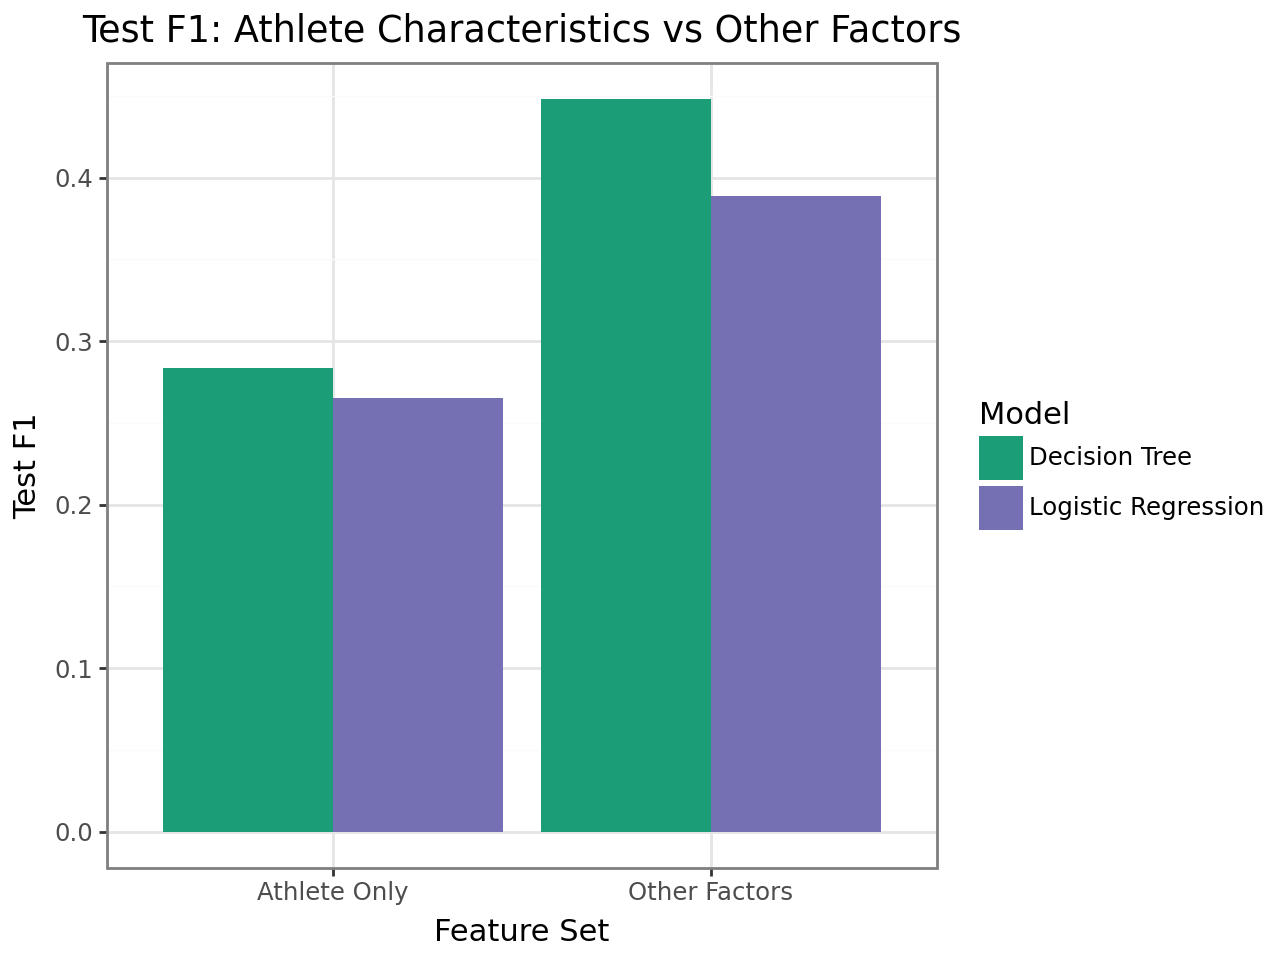

In [ ]:
from plotnine import *

(
    ggplot(
        secondary_results,
        aes(x='Feature_Set', y='Test_F1', fill='Model')
    )
    + geom_col(position='dodge')
    + labs(
        title='Test F1: Athlete Characteristics vs Other Factors',
        x='Feature Set',
        y='Test F1',
        fill='Model'
    )
    + scale_fill_manual(
        values={
            'Logistic Regression': '#7570b3',
            'Decision Tree': '#1b9e77'
        }
    )
    + theme_bw()
)

In [ ]:
import google, json, nbformat

# Get the current notebook and write it to _NOTEBOOK.ipynb

raw_notebook = google.colab._message.blocking_request("get_ipynb",

 timeout_sec=30)["ipynb"]

with open("_NOTEBOOK.ipynb", "w", encoding="utf-8") as ipynb_file:

 ipynb_file.write(json.dumps(raw_notebook))

# Use nbconvert to convert .ipynb to .html.

!jupyter nbconvert --to html --log-level WARN _NOTEBOOK.ipynb

# Download the .html file.

google.colab.files.download("_NOTEBOOK.html")